# Disease Prediction Using Machine Learning and Deep Learning on Breast Cancer Data

**PhD Research Proposal - Preliminary Demonstration**

This notebook demonstrates baseline machine learning and deep learning approaches for cancer diagnosis prediction using the Wisconsin Breast Cancer Dataset. This serves as a preliminary illustration for a broader research agenda on Generative AI for Large-Scale Longitudinal Health Data.

---

## 1. Setup and Data Loading

In [5]:
# Install dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)


In [31]:

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(df.shape)
print(df.head)
print(data.feature_names)

(569, 31)
<bound method NDFrame.head of      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  

## 2. Exploratory Data Analysis (EDA)

In [32]:
# Basic dataset info
df['diagnosis'] = df['target'].map({0:'malignant',1:'benign'})
print('Dataset Info:')
print(f'  Total samples: {len(df)}')
print(f'  Features: {df.shape[1] - 2}')
print(f'  Missing values: {df.isnull().sum().sum()}')
print(f'\nDiagnosis Distribution:')
print(df['diagnosis'].value_counts())


Dataset Info:
  Total samples: 569
  Features: 30
  Missing values: 0

Diagnosis Distribution:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64


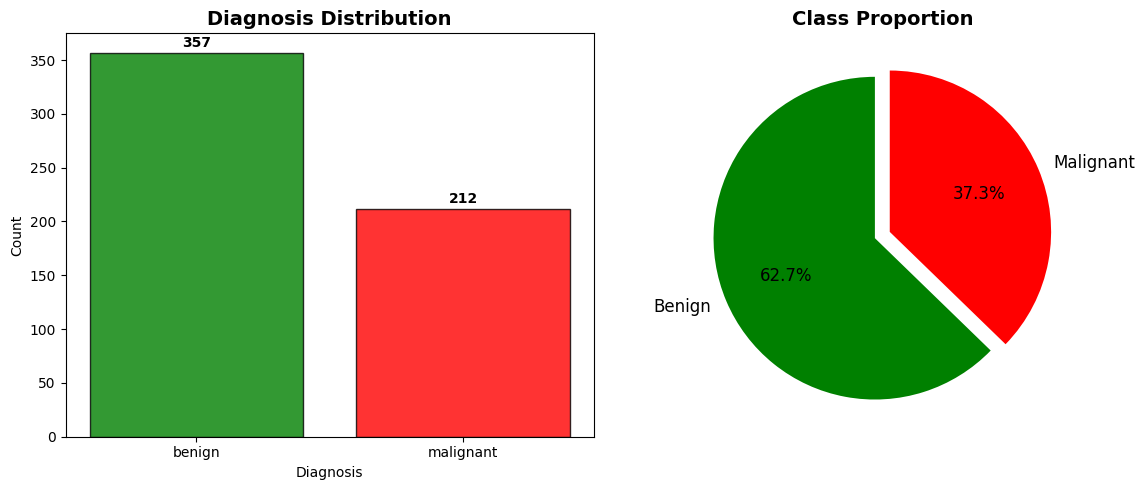

In [33]:
# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['green', 'red']
counts = df['diagnosis'].value_counts()
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Diagnosis Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Benign', 'Malignant'], colors=colors,
            autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05),
            textprops={'fontsize': 12})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


In [34]:
# Statistical summary

print('Statistical Summary of Key Features:')

key_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
                'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points']

df[key_features].describe().round(3)

Statistical Summary of Key Features:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201


## 3. Data Preprocessing

In [45]:
df=df.drop(columns=['diagnosis'])
X = df.drop(columns=['target'])
y = df['target']

print("Encoding already done in sklearn:")
print("0 = malignant, 1 = benign")

print("\nTarget distribution:")
print(y.value_counts())

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

print(f"Missing values in features: {X.isnull().sum().sum()}")

Encoding already done in sklearn:
0 = malignant, 1 = benign

Target distribution:
target
1    357
0    212
Name: count, dtype: int64

Feature matrix shape: (569, 30)
Target vector shape: (569,)
Missing values in features: 0


In [48]:
# Train-test split (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'\nTraining class distribution:\n{y_train.value_counts()}')
print(f'\nTest class distribution:\n{y_test.value_counts()}')

Training set: 455 samples
Test set: 114 samples

Training class distribution:
target
1    285
0    170
Name: count, dtype: int64

Test class distribution:
target
1    72
0    42
Name: count, dtype: int64


In [49]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Feature scaling applied (StandardScaler).')
print(f'Training mean (first 5 features): {X_train_scaled[:, :5].mean(axis=0).round(4)}')
print(f'Training std (first 5 features): {X_train_scaled[:, :5].std(axis=0).round(4)}')

Feature scaling applied (StandardScaler).
Training mean (first 5 features): [-0.  0. -0.  0.  0.]
Training std (first 5 features): [1. 1. 1. 1. 1.]


## 4. Baseline Model Training and Evaluation

In [50]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Train and evaluate each model
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

    results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc,
        'CV Mean': cv_scores.mean(), 'CV Std': cv_scores.std()
    })
    print(f'{name}: Accuracy={acc:.4f}, F1={f1:.4f}, AUC={auc:.4f}, CV={cv_scores.mean():.4f}\u00b1{cv_scores.std():.4f}')

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print('\n' + '='*80)
print('MODEL COMPARISON TABLE')
print('='*80)
results_df.round(4)

Logistic Regression: Accuracy=0.9825, F1=0.9861, AUC=0.9954, CV=0.9802±0.0128
Decision Tree: Accuracy=0.9123, F1=0.9286, AUC=0.9157, CV=0.9099±0.0189
Random Forest: Accuracy=0.9561, F1=0.9655, AUC=0.9939, CV=0.9538±0.0235
Support Vector Machine: Accuracy=0.9825, F1=0.9861, AUC=0.9950, CV=0.9714±0.0179
K-Nearest Neighbors: Accuracy=0.9561, F1=0.9655, AUC=0.9788, CV=0.9670±0.0209
Gradient Boosting: Accuracy=0.9561, F1=0.9660, AUC=0.9907, CV=0.9560±0.0139

MODEL COMPARISON TABLE


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Mean,CV Std
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954,0.9802,0.0128
1,Support Vector Machine,0.9825,0.9861,0.9861,0.9861,0.9950,0.9714,0.0179
2,Random Forest,0.9561,0.9589,0.9722,0.9655,0.9939,0.9538,0.0235
3,Gradient Boosting,0.9561,0.9467,0.9861,0.9660,0.9907,0.9560,0.0139
4,K-Nearest Neighbors,0.9561,0.9589,0.9722,0.9655,0.9788,0.9670,0.0209
5,Decision Tree,0.9123,0.9559,0.9028,0.9286,0.9157,0.9099,0.0189


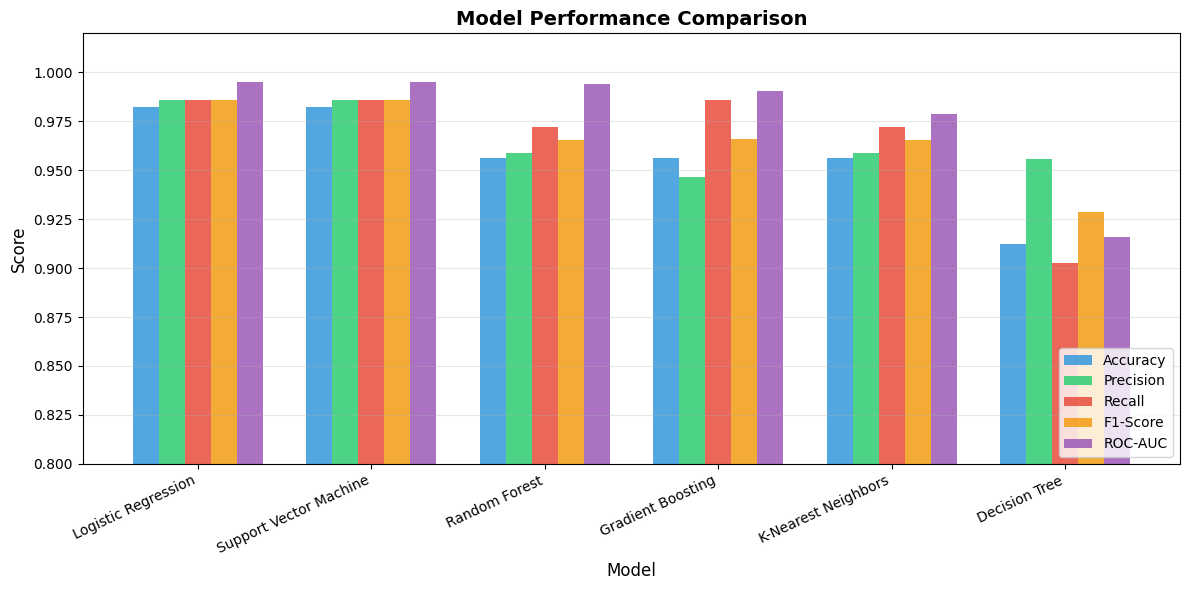

Figure saved: fig4_model_comparison.png


In [51]:
# Model comparison bar chart
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.15
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=colors_bar[i], alpha=0.85)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['Model'], rotation=25, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0.8, 1.02)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Detailed Analysis of Best Models

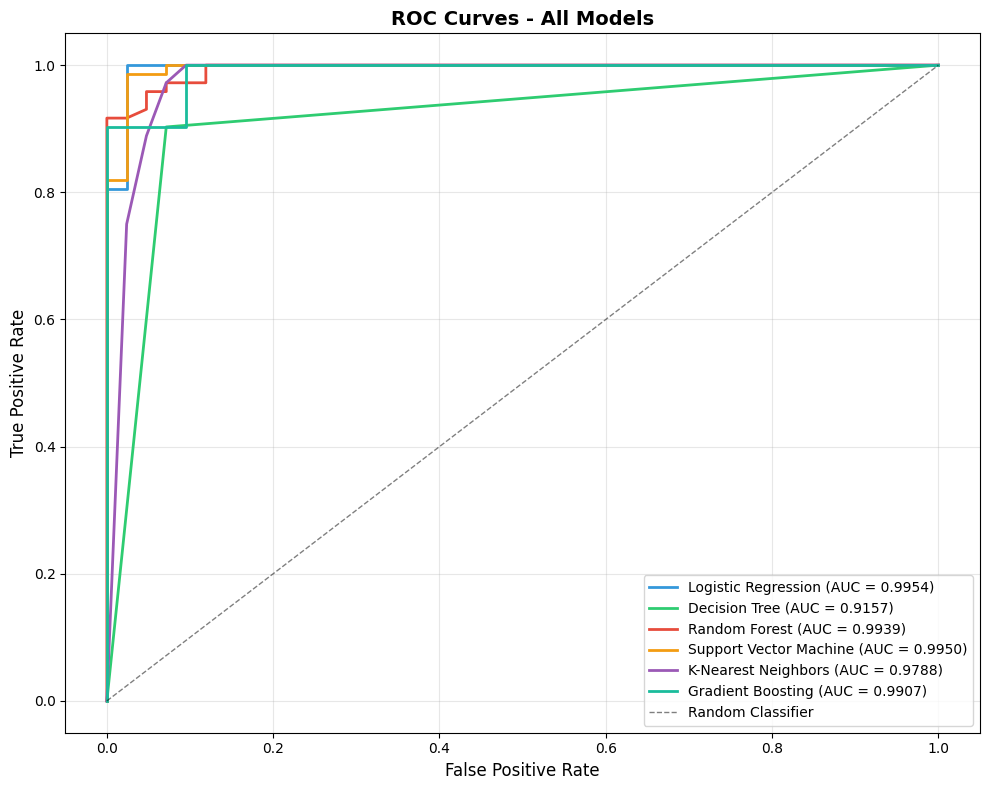

Figure saved: fig5_roc_curves.png


In [52]:
# ROC Curves for all models
plt.figure(figsize=(10, 8))
colors_roc = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

for idx, (name, model) in enumerate(models.items()):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=colors_roc[idx], lw=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


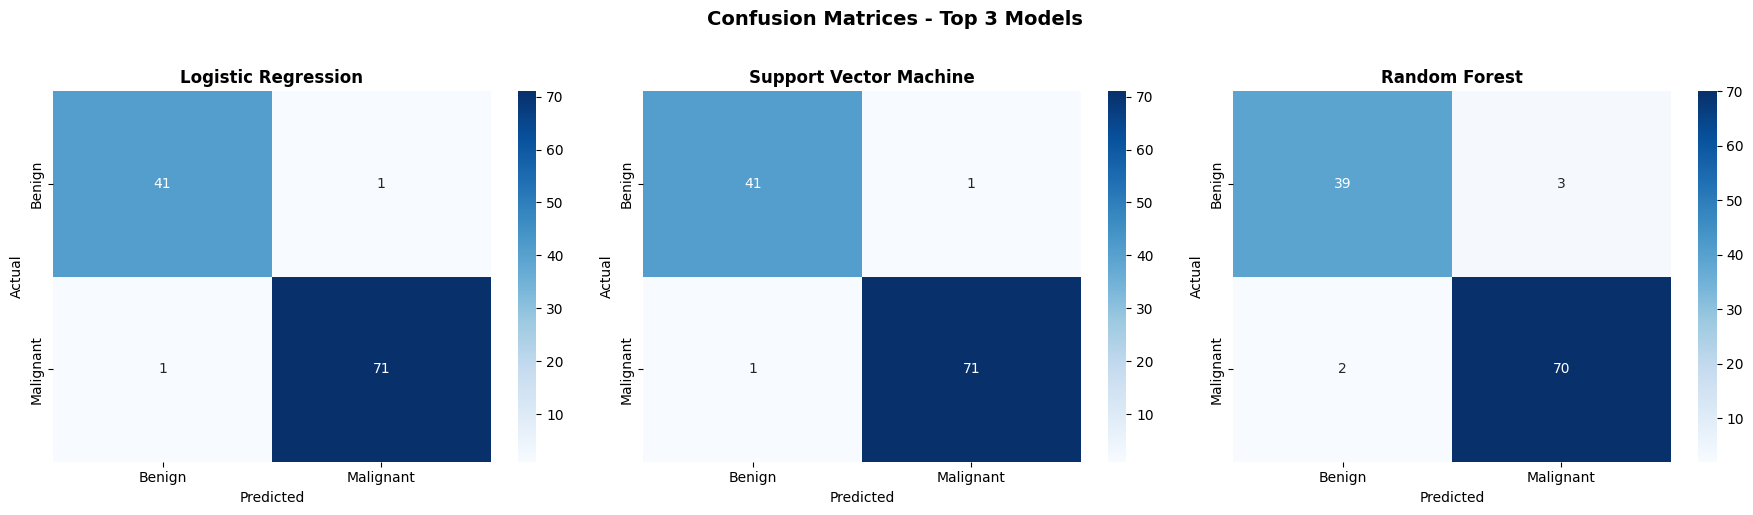

Figure saved: fig6_confusion_matrices.png


In [53]:
# Confusion matrices for top 3 models
top_models = results_df.head(3)['Model'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, name in enumerate(top_models):
    model = models[name]
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrices - Top 3 Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


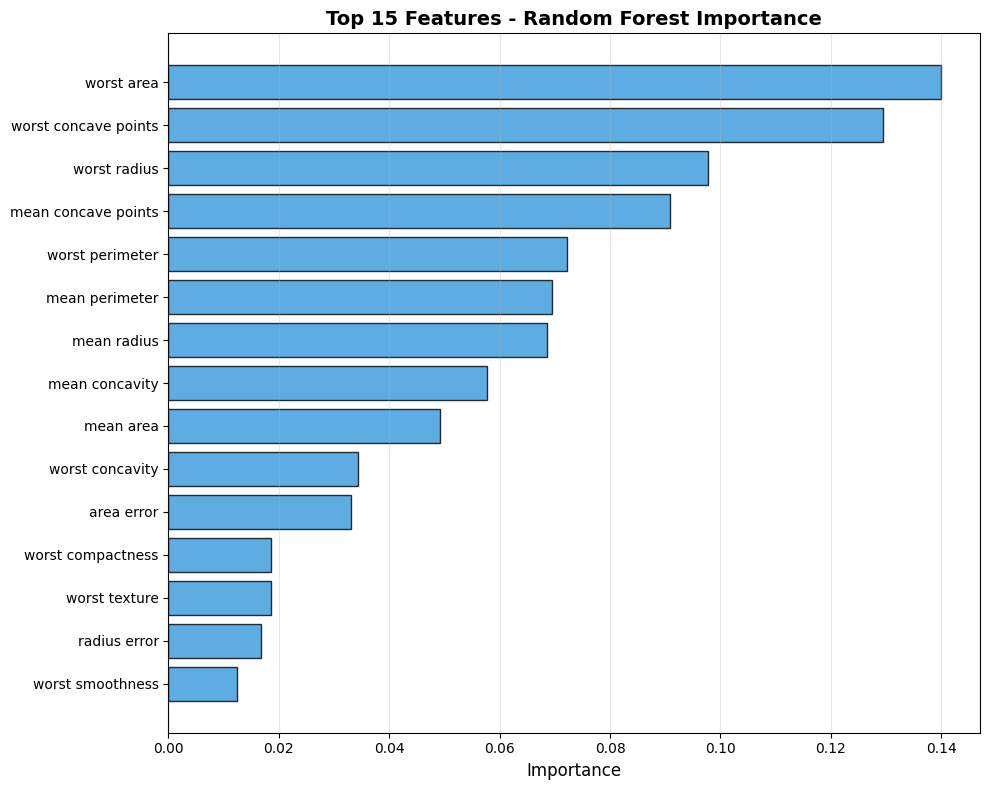

Figure saved: fig7_feature_importance.png


In [54]:
# Feature importance from Random Forest
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': X.columns, 'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'],
         color='#3498db', edgecolor='black', alpha=0.8)
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 Features - Random Forest Importance', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


In [55]:
# Classification report for the best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f'Best Model: {best_model_name}')
print('='*60)
print(classification_report(y_test, y_pred_best, target_names=['Benign', 'Malignant']))

Best Model: Logistic Regression
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98        42
   Malignant       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 6. Cross-Validation Analysis

Logistic Regression: 0.9772 ± 0.0176
Decision Tree: 0.9262 ± 0.0233
Random Forest: 0.9561 ± 0.0239
Support Vector Machine: 0.9754 ± 0.0195
K-Nearest Neighbors: 0.9701 ± 0.0176
Gradient Boosting: 0.9596 ± 0.0249


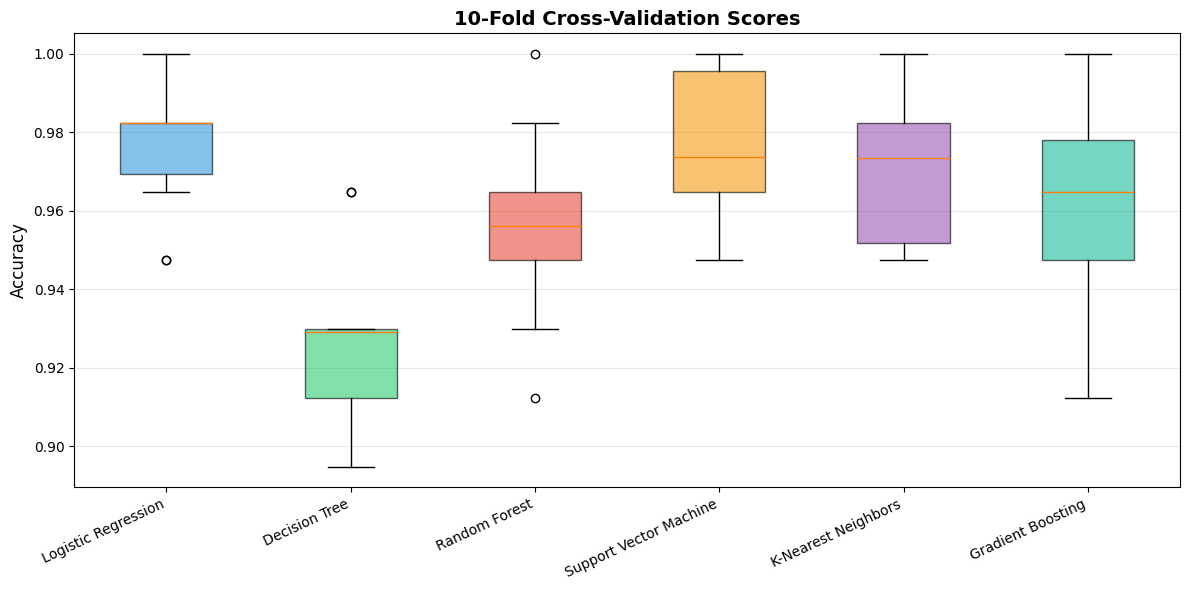

Figure saved: fig8_cross_validation.png


In [56]:
# 10-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, scaler.fit_transform(X), y, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name}: {scores.mean():.4f} \u00b1 {scores.std():.4f}')

plt.figure(figsize=(12, 6))
bp = plt.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True)
for patch, color in zip(bp['boxes'], colors_roc):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.ylabel('Accuracy', fontsize=12)
plt.title('10-Fold Cross-Validation Scores', fontsize=14, fontweight='bold')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Deep Learning Approach — Neural Network Classifier



In [57]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

print(f'TensorFlow version: {tf.__version__}')
tf.random.set_seed(42)

# Build a feedforward neural network
def build_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

nn_model = build_model(X_train_scaled.shape[1])
nn_model.summary()

TensorFlow version: 2.19.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,105 (59.00 KB)

 Trainable params: 14,721 (57.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [58]:
# Train the neural network
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print('\nTraining complete!')

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.7253 - auc: 0.7462 - loss: 0.5956 - val_accuracy: 0.9231 - val_auc: 0.9789 - val_loss: 0.4819 - learning_rate: 0.0010
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8819 - auc: 0.9550 - loss: 0.2820 - val_accuracy: 0.9560 - val_auc: 0.9896 - val_loss: 0.3670 - learning_rate: 0.0010
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9148 - auc: 0.9712 - loss: 0.2168 - val_accuracy: 0.9560 - val_auc: 0.9940 - val_loss: 0.2985 - learning_rate: 0.0010
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9423 - auc: 0.9822 - loss: 0.1734 - val_accuracy: 0.9670 - val_auc: 0.9973 - val_loss: 0.2528 - learning_rate: 0.0010
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9533 - auc: 0.9870 - loss: 0.1491 - val_accuracy: 0.9670 - val_auc: 0.9980 - val_loss: 0.2191 - learning_rate: 0.0010
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9615 - auc: 0.

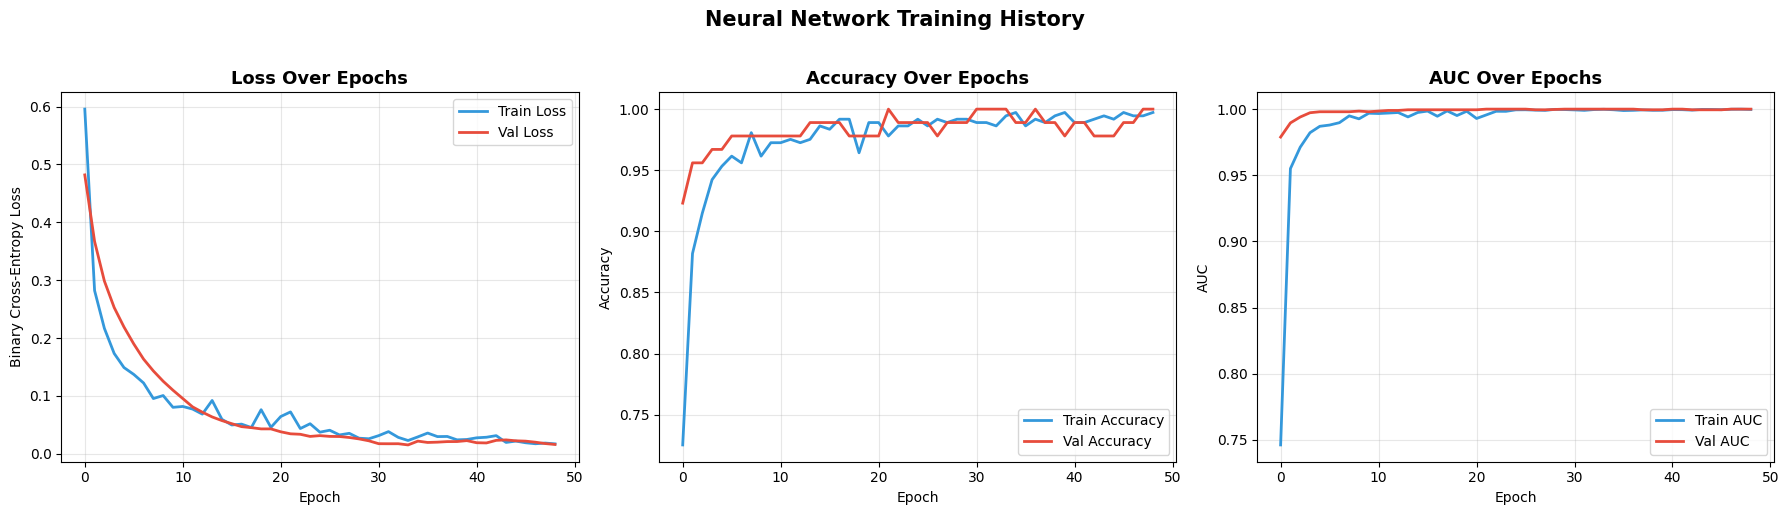

Figure saved: fig9_nn_training_history.png


In [59]:
# Training history plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color='#3498db', lw=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', lw=2)
axes[0].set_title('Loss Over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='#3498db', lw=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='#e74c3c', lw=2)
axes[1].set_title('Accuracy Over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history.history['auc'], label='Train AUC', color='#3498db', lw=2)
axes[2].plot(history.history['val_auc'], label='Val AUC', color='#e74c3c', lw=2)
axes[2].set_title('AUC Over Epochs', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Neural Network Training History', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig9_nn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig9_nn_training_history.png')

In [60]:
# Evaluate neural network on test set
nn_loss, nn_acc, nn_auc = nn_model.evaluate(X_test_scaled, y_test, verbose=0)
y_pred_nn_prob = nn_model.predict(X_test_scaled, verbose=0).flatten()
y_pred_nn = (y_pred_nn_prob >= 0.5).astype(int)

nn_prec = precision_score(y_test, y_pred_nn)
nn_rec = recall_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn)
nn_roc = roc_auc_score(y_test, y_pred_nn_prob)

print('='*60)
print('NEURAL NETWORK RESULTS')
print('='*60)
print(f'Accuracy:  {nn_acc:.4f}')
print(f'Precision: {nn_prec:.4f}')
print(f'Recall:    {nn_rec:.4f}')
print(f'F1-Score:  {nn_f1:.4f}')
print(f'ROC-AUC:   {nn_roc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_nn, target_names=['Benign', 'Malignant']))

NEURAL NETWORK RESULTS
Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1-Score:  0.9861
ROC-AUC:   0.9954

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98        42
   Malignant       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [61]:
# Compare Neural Network with all classical ML models
nn_result = {
    'Model': 'Neural Network (Keras)', 'Accuracy': nn_acc, 'Precision': nn_prec,
    'Recall': nn_rec, 'F1-Score': nn_f1, 'ROC-AUC': nn_roc,
    'CV Mean': np.nan, 'CV Std': np.nan
}
all_results_df = pd.concat([results_df, pd.DataFrame([nn_result])], ignore_index=True)
all_results_df = all_results_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print('='*80)
print('ALL MODELS COMPARISON (Classical ML + Deep Learning)')
print('='*80)
print(all_results_df.round(4).to_string(index=False))

ALL MODELS COMPARISON (Classical ML + Deep Learning)
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV Mean  CV Std
   Logistic Regression    0.9825     0.9861  0.9861    0.9861   0.9954   0.9802  0.0128
Neural Network (Keras)    0.9825     0.9861  0.9861    0.9861   0.9954      NaN     NaN
Support Vector Machine    0.9825     0.9861  0.9861    0.9861   0.9950   0.9714  0.0179
         Random Forest    0.9561     0.9589  0.9722    0.9655   0.9939   0.9538  0.0235
     Gradient Boosting    0.9561     0.9467  0.9861    0.9660   0.9907   0.9560  0.0139
   K-Nearest Neighbors    0.9561     0.9589  0.9722    0.9655   0.9788   0.9670  0.0209
         Decision Tree    0.9123     0.9559  0.9028    0.9286   0.9157   0.9099  0.0189


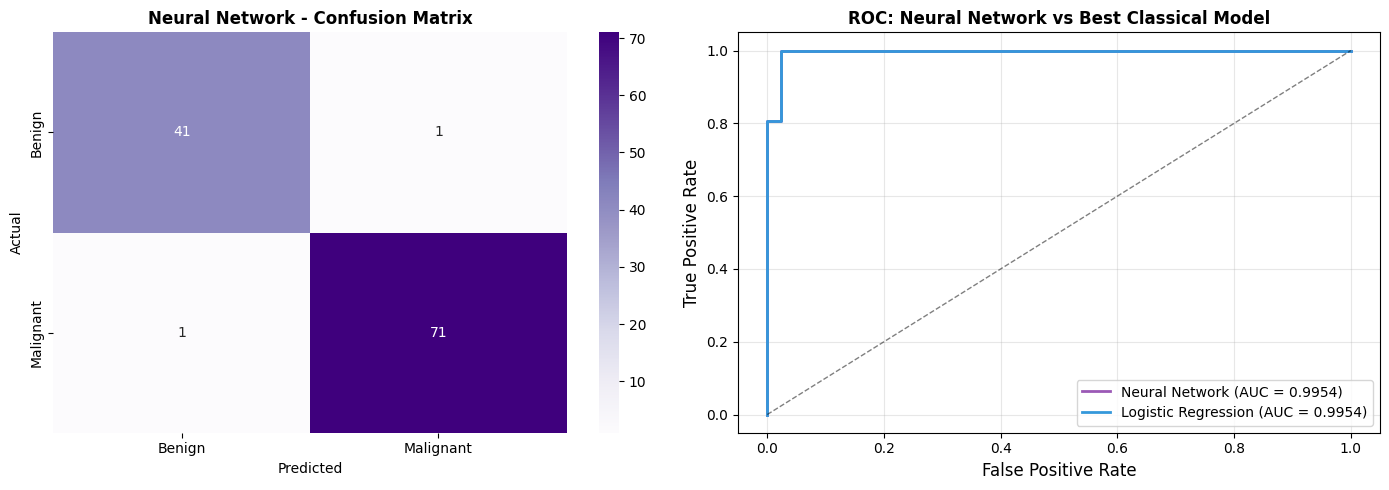

Figure saved: fig10_nn_evaluation.png


In [62]:
# Neural Network: Confusion Matrix and ROC comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_nn = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[0].set_title('Neural Network - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_pred_nn_prob)
axes[1].plot(fpr_nn, tpr_nn, color='#9b59b6', lw=2, label=f'Neural Network (AUC = {nn_roc:.4f})')

best_classical = results_df.iloc[0]['Model']
y_prob_best = models[best_classical].predict_proba(X_test_scaled)[:, 1]
fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best)
auc_best = roc_auc_score(y_test, y_prob_best)
axes[1].plot(fpr_best, tpr_best, color='#3498db', lw=2, label=f'{best_classical} (AUC = {auc_best:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC: Neural Network vs Best Classical Model', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig10_nn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig10_nn_evaluation.png')

## 8. Summary and Final Results

In [63]:
# Final results summary
print('='*80)
print('FINAL RESULTS SUMMARY')
print('='*80)
print(f'\nDataset: Wisconsin Breast Cancer Diagnostic Dataset')
print(f'Samples: {len(df)} | Features: {X.shape[1]} | Classes: 2 (Benign/Malignant)')
print(f'Train/Test Split: 80/20 (stratified)')
print(f'Scaling: StandardScaler')
print(f'\n{all_results_df.round(4).to_string(index=False)}')
print(f'\nBest Overall Model: {all_results_df.iloc[0]["Model"]}')
print(f'  Accuracy: {all_results_df.iloc[0]["Accuracy"]:.4f}')
print(f'  ROC-AUC:  {all_results_df.iloc[0]["ROC-AUC"]:.4f}')
print(f'  F1-Score: {all_results_df.iloc[0]["F1-Score"]:.4f}')

FINAL RESULTS SUMMARY

Dataset: Wisconsin Breast Cancer Diagnostic Dataset
Samples: 569 | Features: 30 | Classes: 2 (Benign/Malignant)
Train/Test Split: 80/20 (stratified)
Scaling: StandardScaler

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV Mean  CV Std
   Logistic Regression    0.9825     0.9861  0.9861    0.9861   0.9954   0.9802  0.0128
Neural Network (Keras)    0.9825     0.9861  0.9861    0.9861   0.9954      NaN     NaN
Support Vector Machine    0.9825     0.9861  0.9861    0.9861   0.9950   0.9714  0.0179
         Random Forest    0.9561     0.9589  0.9722    0.9655   0.9939   0.9538  0.0235
     Gradient Boosting    0.9561     0.9467  0.9861    0.9660   0.9907   0.9560  0.0139
   K-Nearest Neighbors    0.9561     0.9589  0.9722    0.9655   0.9788   0.9670  0.0209
         Decision Tree    0.9123     0.9559  0.9028    0.9286   0.9157   0.9099  0.0189

Best Overall Model: Logistic Regression
  Accuracy: 0.9825
  ROC-AUC:  0.9954
  F1-Score: 0.9861


## 9. Discussion and Future Directions

### Key Findings
- Multiple baseline ML models achieve strong classification performance on the breast cancer dataset
- Linear and kernel-based methods demonstrated the most consistent performance for this dataset.
- The deep learning neural network achieves competitive performance, demonstrating the potential of neural approaches for health data
- Features related to cell size (radius, perimeter, area) and shape (concavity, concave points) are the most predictive

### Limitations of Current Approach
- This dataset is **cross-sectional** (single snapshot per patient), not longitudinal
- Does not capture disease progression, treatment responses, or temporal patterns
- Limited to 569 samples — real healthcare registries contain millions of records

### Proposed Extensions for PhD Research
1. **Longitudinal modelling**: Extend to sequential patient data from health registries to capture disease trajectories over time
2. **Transformer-based models**: Apply attention-based architectures (inspired by LLMs) to learn temporal patterns in patient event sequences
3. **Generative AI**: Use VAEs, GANs, and autoregressive transformers to generate realistic synthetic patient health trajectories
5. **Trajectory evaluation**: Develop novel metrics to evaluate the clinical realism of generated health trajectories beyond standard accuracy

These extensions align directly with the PhD research objectives in **Generative AI for Large-Scale Longitudinal Health Data** at Politecnico di Milano, supervised by Prof. Ieva and Prof. Di Angelantonio.